# **TRABAJO PRÁCTICO - COMPUTER VISION**
## Tecnicatura Universitaria en Inteligencia Artificial
### Integrantes:
-  Sancho Almenar, Mariano S-5778/9



## Objetivo General

Desarrollar un pipeline completo de visión por computadora para la identificación de razas de perros en imágenes. El proyecto abarca desde la creación de un sistema de búsqueda por similitud hasta la implementación de un sistema de detección y clasificación en imágenes complejas, incluyendo el entrenamiento y la optimización de modelos de Deep Learning.

# Preparación de Entorno

In [1]:
!pip install -q gdown
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 66.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import zipfile
import gdown
import random
from collections import defaultdict, Counter
import faiss
import gradio as gr
from tqdm import tqdm
import tempfile
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import History, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Input, RandomFlip, RandomContrast, RandomTranslation, Flatten, Dropout, Dense, Conv2D, Activation, MaxPooling2D, Rescaling, Resizing, BatchNormalization
from tensorflow.keras.optimizers import Adam

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

In [4]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


# Descarga y Preparación del Dataset

## Descarga y unzip

In [5]:
!gdown --fuzzy "https://drive.google.com/file/d/1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm/view?usp=sharing" -O dataset.zip

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

Downloading...
From (original): https://drive.google.com/uc?id=1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm
From (redirected): https://drive.google.com/uc?id=1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm&confirm=t&uuid=50348d14-3e86-4e34-88b9-11773a618c85
To: /content/dataset.zip
100% 225M/225M [00:03<00:00, 64.1MB/s]


## Conversión a TensorFlow Dataset

In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 7946 files belonging to 70 classes.
Found 700 files belonging to 70 classes.
Found 700 files belonging to 70 classes.


## EDA

### Cantidad de Clases

In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"El dataset cuenta con un total de {num_classes} clases")
print(class_names)


El dataset cuenta con un total de 70 clases
['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberian Husky', 'Vizsla', 'Yorkie']


### Distribución de imágenes por clase

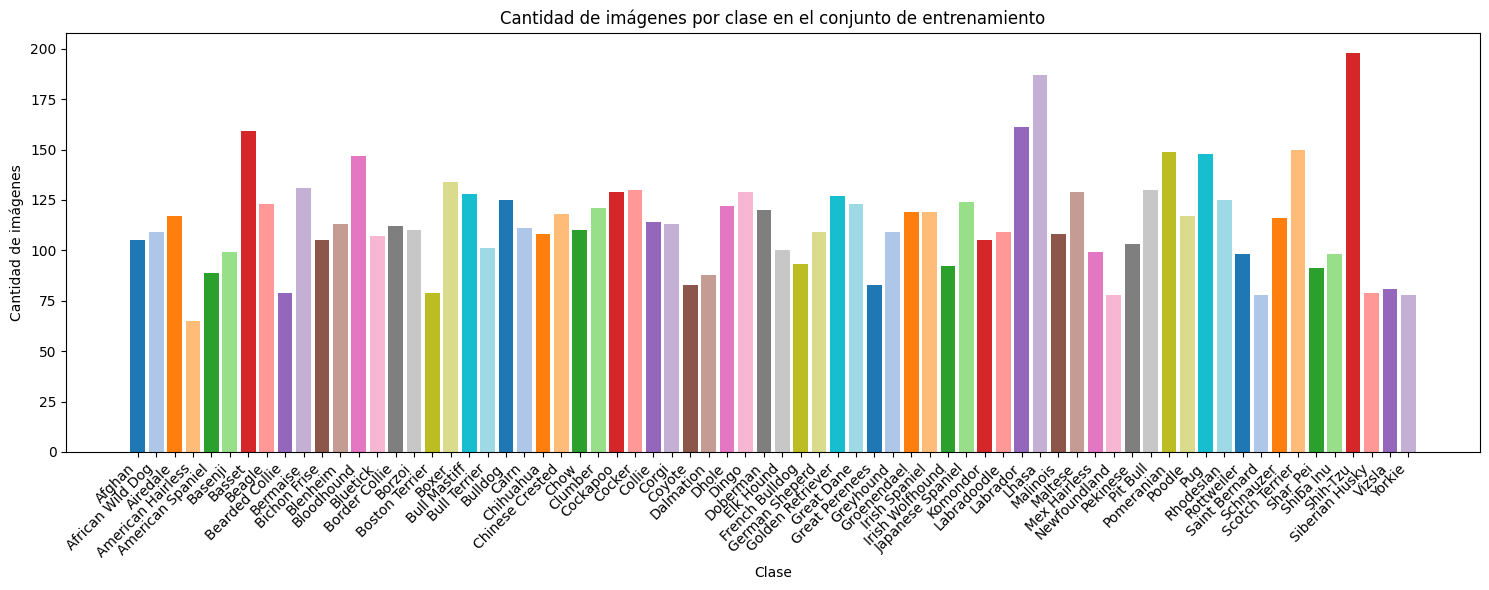

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = np.zeros(len(class_names), dtype=int)

for _, labels in train_ds.unbatch():
    class_index = tf.argmax(labels).numpy()
    class_counts[class_index] += 1


plt.figure(figsize=(15, 6))
bars = plt.bar(class_names, class_counts, color=plt.cm.tab20.colors[:len(class_names)])

plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Cantidad de imágenes por clase en el conjunto de entrenamiento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Se observa que no hay un gran balanceo entre clases. Siendo 'Shih-Tzu' la clase con mayor cantidad de imágenes (198) y 'American Hairless' con 68

## Visualización de algunas imágenes

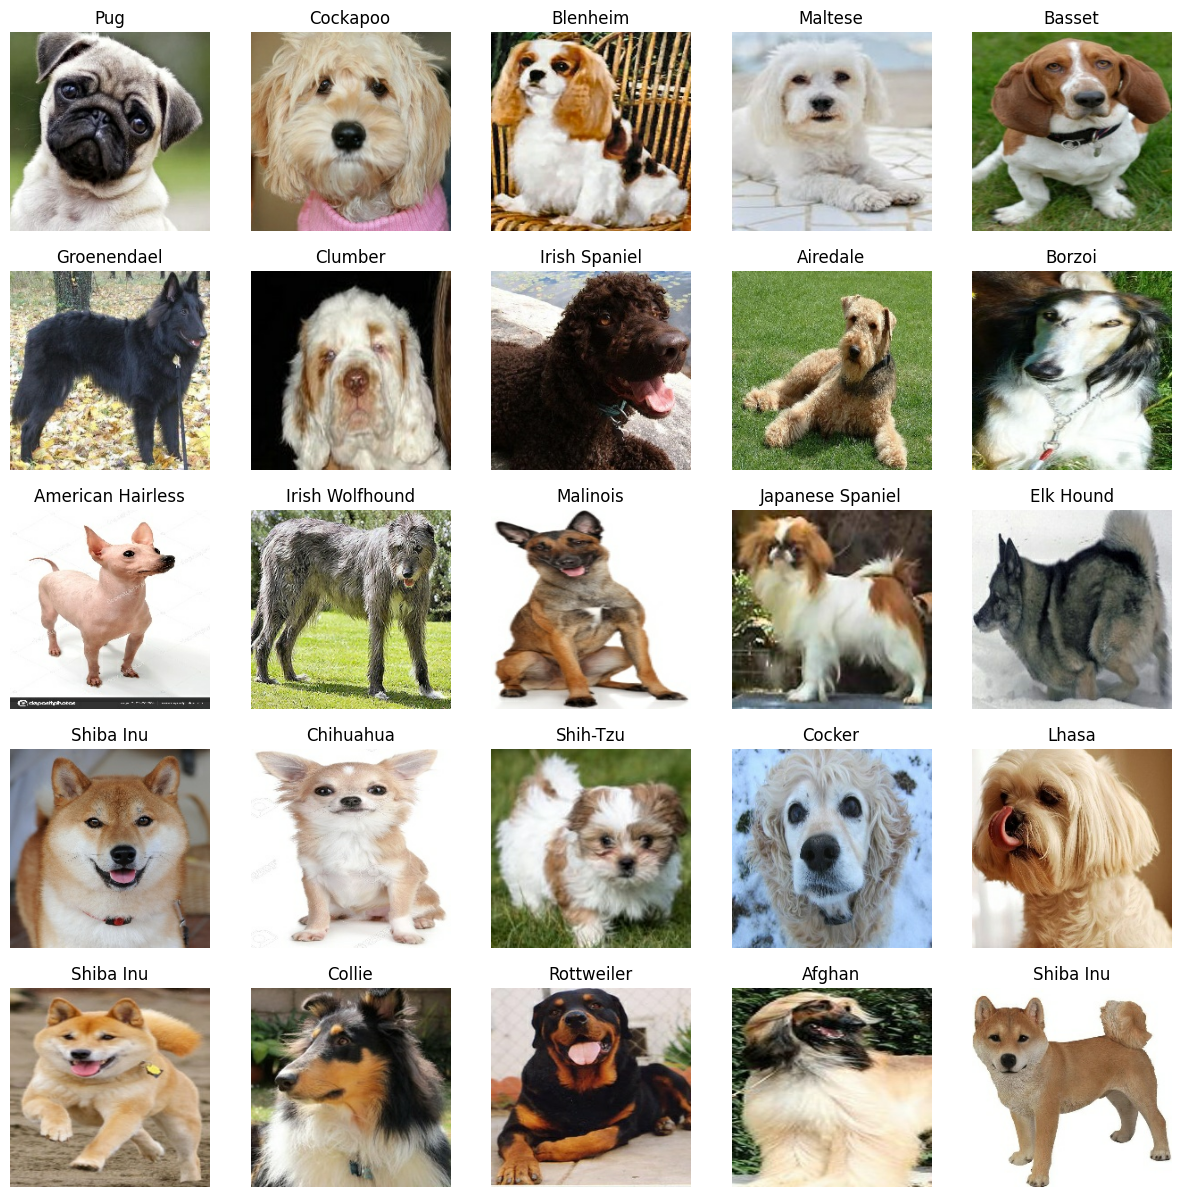

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in train_ds.take(1):
  for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    class_idx = list(labels[i]).index(1)
    plt.title(class_names[class_idx])
    plt.axis("off")

# **Etapa 1**:  Buscador de Imágenes por Similitud

## Creación de la Base de Datos Vectorial


In [ ]:
# 1. Cargar modelo pre-entrenado
print("Cargando modelo ResNet50...")
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# 2. Configuración FAISS
dimension = 2048  # Dimensión de los embeddings de ResNet50
nlist = 70
quantizer = faiss.IndexFlatL2(dimension)
index = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

def prepare_faiss_index(dataset, model):
    all_features = []
    image_paths = []
    image_labels = []

    temp_dir = tempfile.mkdtemp()
    class_names = dataset.class_names

    for batch_idx, batch in enumerate(tqdm(dataset, desc="Procesando dataset")):
        images, labels = batch

        x = preprocess_input(images)
        features = model.predict(x, verbose=0)
        all_features.append(features)

        for img_idx, (img, label) in enumerate(zip(images, labels)):
            path = os.path.join(temp_dir, f"b{batch_idx}_i{img_idx}.jpg")
            tf.keras.utils.save_img(path, img)
            image_paths.append(path)
            image_labels.append(class_names[int(np.argmax(label.numpy()))])

    all_features = np.concatenate(all_features, axis=0).astype('float32')

    print("Entrenando índice FAISS...")
    index.train(all_features)
    index.add(all_features)

    return index, image_paths, image_labels

print("Preparando índice FAISS con train_ds...")


faiss_index, image_paths, image_labels = prepare_faiss_index(train_ds, model)

Cargando modelo ResNet50...
94765736/94765736 [==============================] - 6s 0us/step
Preparando índice FAISS con train_ds...


Procesando dataset:   0%|          | 0/249 [00:00<?, ?it/s]2025-06-25 23:18:51.959920: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-06-25 23:18:52.245308: W tensorflow/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2025-06-25 23:18:55.005485: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.21GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more mem

Entrenando índice FAISS...


## Clasificación Basada en Similitud y Métrica de Evaluación

### Búsqueda de imágenes similares


In [ ]:
# 5. Buscar imágenes similares con predicción de raza
def find_similar_images(img_tensor, k=10):
    img = tf.image.resize(img_tensor, [224, 224])
    img = tf.expand_dims(img, axis=0)
    img = preprocess_input(img)

    query_features = model.predict(img, verbose=0).astype('float32')
    distances, indices = faiss_index.search(query_features, k)

    similar_images = [(image_paths[i], image_labels[i], float(distances[0][j]))
                     for j, i in enumerate(indices[0])]

    breeds = [label for _, label, _ in similar_images]
    breed_counts = Counter(breeds)
    predicted_breed = breed_counts.most_common(1)[0][0]

    return similar_images, predicted_breed

### NDCG

In [ ]:
def select_test_subset(dataset, k=5):
  """
  Selecciona aleatoreamente k imágenes del dataset
  """

  class_to_images = defaultdict(list)

  for batch in dataset:
      images, labels = batch
      for img_tensor, label_tensor in zip(images, labels):
          class_index = int(np.argmax(label_tensor.numpy()))
          class_name = train_ds.class_names[class_index]
          class_to_images[class_name].append((img_tensor, class_name))

  # Paso 2: Tomar 5-10 imágenes por clase
  test_subset = []

  for class_name, samples in class_to_images.items():
      selected = random.sample(samples, k=min(len(samples), 10))[:k]
      test_subset.extend(selected)

  print(f"Total de imágenes seleccionadas: {len(test_subset)}")

  return test_subset

In [ ]:
def ndcg_at_k(true_label, pred_labels, k=10):
    relevances = [1 if label == true_label else 0 for label in pred_labels[:k]]
    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevances)])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, sum(relevances)))])
    return dcg / idcg if idcg > 0 else 0

In [ ]:
ndcg_scores = []
test_subset = select_test_subset(test_ds, 6)

for img_tensor, true_label in test_subset:
    similar_images, _ = find_similar_images(img_tensor)
    retrieved_labels = [label for _, label, _ in similar_images]

    score = ndcg_at_k(true_label, retrieved_labels, k=10)
    ndcg_scores.append(score)

average_ndcg = np.mean(ndcg_scores)
print(f"NDCG@10 promedio sobre subconjunto de prueba: {average_ndcg:.4f}")

Total de imágenes seleccionadas: 420


NameError: name 'find_similar_images' is not defined

## Interfaz de Gradio

In [ ]:
from functools import partial
def gradio_interface(img_tensor, average_ndcg):
    similar_images, predicted_breed = find_similar_images(img_tensor)
    output_imgs = [plt.imread(img_path) for img_path, _, _ in similar_images]
    ndcg_text = round(average_ndcg, 2)
    return output_imgs, predicted_breed, ndcg_text


iface = gr.Interface(
    fn=partial(gradio_interface, average_ndcg=average_ndcg),
    inputs=gr.Image(type="numpy", label="Sube una imagen de perro"),
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="NDCG@10 promedio sobre subconjunto de prueba")
    ],
    title="Buscador de similitud y clasificación de razas de perros",
    description="Sube una imagen de perro para encontrar imágenes similares y predecir su raza."
)

iface.launch()

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


# **Etapa 2**: Entrenamiento y Comparación de modelos de Clasificación

## Entrenamiento de Modelos

#### Definición de funciones y clases

In [ ]:
def acc_loss_plot(model_history : History) -> None:
    """
    Función para graficar accuracy y loss para train y validación

    Args:
        model_history: Historia de entrenamiento modelo
    """

    plt.figure(figsize=(10, 8))

    # Accuracy
    plt.subplot(2, 2, 1)
    plt.title("Accuracy Train/Validacion con respecto a las épocas")
    plt.plot(model_history.history['accuracy'], label='Train Accuracy')
    plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(2, 2, 2)
    plt.title("Loss Train/Validacion con respecto a las épocas")
    plt.plot(model_history.history['loss'], label='Train Loss')
    plt.plot(model_history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, 3])
    plt.legend(loc='upper right')

In [8]:
# Se crea la Clase History para almacenar los historiales de entrenamiento en los modelos de Resnet18 para luego graficarlos
class History:
    def __init__(self):
        self.history = {
            'accuracy': [],
            'val_accuracy': [],
            'loss': [],
            'val_loss': []
        }

In [16]:
def train_model(model, trainloader, validloader, criterion, optimizer, scheduler, num_epochs=10, device='cpu', save_path='model.pth'):
    """
    Entrena un modelo y guarda el mejor según validación.

    Args:
        model: modelo a entrenar (ya configurado)
        trainloader: DataLoader de entrenamiento
        validloader: DataLoader de validación
        criterion: función de pérdida
        optimizer: optimizador
        scheduler: scheduler de LR
        num_epochs: número de épocas a entrenar
        device: 'cuda' o 'cpu'
        save_path: ruta para guardar el mejor modelo

    Returns:
        history: objeto History con métricas de entrenamiento/validación
    """
    best_acc = 0.0
    history = History()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(trainloader)

        # Validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item()
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / val_total
        val_loss /= len(validloader)

        # Guardar historial
        history.history['accuracy'].append(train_acc)
        history.history['val_accuracy'].append(val_acc)
        history.history['loss'].append(train_loss)
        history.history['val_loss'].append(val_loss)

        # Guardar mejor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Mejor modelo guardado")

        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - "
              f"Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}")

    print("Entrenamiento finalizado")

    return model, history

In [10]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import models

def get_predictions(model, dataloader, device):
    """
    Obtiene predicciones del modelo para un dataloader dado.

    Args:
        model (nn.Module): Modelo de PyTorch ya entrenado
        dataloader (DataLoader): DataLoader con los datos a evaluar
        device (torch.device): Dispositivo donde se ejecutará el modelo ('cpu' o 'cuda')

    Returns:
        tuple: (imagenes, etiquetas_reales, etiquetas_predichas, probabilidades)
    """
    model.eval()  # Aseguramos que el modelo esté en modo evaluación
    all_images = []
    true_labels = []
    pred_labels = []


    with torch.no_grad():  # Desactivamos el cálculo de gradientes
        for images, labels in dataloader:
            # Mover datos al dispositivo (GPU/CPU)
            images = images.to(device)
            labels = labels.to(device)

            # Obtener predicciones
            outputs = model(images)

            # Calcular probabilidades y clases predichas
            _, predicted = torch.max(outputs, 1)

            # Guardar resultados
            all_images.append(images.cpu())
            true_labels.append(labels.cpu())
            pred_labels.append(predicted.cpu())


    # Concatenar todos los batches
    all_images = torch.cat(all_images, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    pred_labels = torch.cat(pred_labels, dim=0)


    return all_images, true_labels, pred_labels

In [33]:
def get_preds_labels_tf(model, dataset):
    """
    Obtiene las predicciones y etiquetas verdaderas de un dataset de TensorFlow,
    y las convierte a nombres de clases.

    Args:
        model: modelo TensorFlow/Keras
        dataset: tf.data.Dataset con atributo class_names

    Returns:
        y_true: lista de etiquetas verdaderas (nombres)
        y_pred: lista de etiquetas predichas (nombres)
    """
    y_true = []
    y_pred = []
    class_names = dataset.class_names

    for images, labels in dataset:
        preds = model.predict(images)
        preds_classes = np.argmax(preds, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)

        y_pred.extend(preds_classes)
        y_true.extend(true_classes)

    # Convertir índices a nombres
    y_true_names = [class_names[i] for i in y_true]
    y_pred_names = [class_names[i] for i in y_pred]

    return y_true_names, y_pred_names

In [11]:
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, classes=None, title='Matriz de Confusión'):
    """
    Genera y muestra una matriz de confusión usando Plotly, sin normalización.

    Args:
        y_true: lista o array de etiquetas reales
        y_pred: lista o array de etiquetas predichas
        classes: lista de nombres de clases (opcional)
        title: título del gráfico
    """
    cm = confusion_matrix(y_true, y_pred)

    if classes is None:
        classes = [str(i) for i in range(len(cm))]

    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=classes,
        y=classes,
        colorscale='Blues',
        hoverongaps=False,
        text=cm,
        texttemplate="%{text}",
        colorbar=dict(title='Frecuencia')
    ))

    fig.update_layout(
        title=title,
        xaxis_title='Predicción',
        yaxis_title='Etiqueta Real',
        yaxis=dict(autorange='reversed'),
        width=1200,
        height=1200
    )

    fig.show()

### Transfer Learning

Se importa el modelo ResNet18 preentrenado y luego se le realizará un fine-tunning.

Se evaluará el desempeño tanto del modelo base como el modificado.

In [20]:
# Para entrenamiento (con data augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Aumento de datos (opcional)
    transforms.ToTensor(),  # Convierte a tensor y escala a [0, 1] (CxHxW)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Valores estándar para ImageNet
])

# Para validación y test (sin aumentos)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar datasets
trainset = datasets.ImageFolder(root='./data/train', transform=train_transform)
validset = datasets.ImageFolder(root='./data/valid', transform=test_transform)
testset  = datasets.ImageFolder(root='./data/test',  transform=test_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

#### Modelo Base

Entrena sólo la capa final

In [13]:
import os
os.makedirs('models', exist_ok=True)

In [14]:
rn18_model = models.resnet18(pretrained=True)

# Modificar la última capa para el número de clases
rn18_model.fc = nn.Linear(rn18_model.fc.in_features, len(class_names))

# Congelar todos los parámetros
for param in rn18_model.parameters():
    param.requires_grad = False

# Descongelar parámetros de la última capa
for param in rn18_model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rn18_model = rn18_model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, rn18_model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 74.1MB/s]


In [21]:
# Entrenamiento
base_model, base_history = train_model(rn18_model,
                           trainloader,
                           validloader,
                           criterion,
                           optimizer,
                           scheduler,
                           num_epochs=5,
                           device=device,
                           save_path='models/base_model.pth')

✅ Mejor modelo guardado
Epoch [1/5] - Loss: 1.6789 - Acc: 0.6422 - Val_Loss: 0.7358 - Val_Acc: 0.8671
✅ Mejor modelo guardado
Epoch [2/5] - Loss: 0.5933 - Acc: 0.8632 - Val_Loss: 0.5869 - Val_Acc: 0.8957
✅ Mejor modelo guardado
Epoch [3/5] - Loss: 0.4451 - Acc: 0.8875 - Val_Loss: 0.5754 - Val_Acc: 0.9029
Epoch [4/5] - Loss: 0.3701 - Acc: 0.8979 - Val_Loss: 0.5782 - Val_Acc: 0.8943
Epoch [5/5] - Loss: 0.3176 - Acc: 0.9128 - Val_Loss: 0.5647 - Val_Acc: 0.9014
Entrenamiento finalizado


In [22]:
images, true_labels_base, pred_labels_base = get_predictions(model=base_model, dataloader=testloader, device=device)

In [23]:
plot_confusion_matrix(true_labels_base, pred_labels_base, classes = testloader.dataset.classes, title='Base ResNet18 - Matriz de Confusión')

### Fine-Tuning ResNet18

In [26]:
# Modelo fine-tuned (todas las capas entrenables)
ft_rn18_model = models.resnet18(pretrained=True)
ft_rn18_model.fc = nn.Linear(ft_rn18_model.fc.in_features, len(class_names))

for param in ft_rn18_model.parameters():
    param.requires_grad = True
ft_rn18_model = ft_rn18_model.to(device)

ft_rn18_optimizer = optim.Adam(ft_rn18_model.parameters(), lr=1e-4)
ft_rn18_scheduler = optim.lr_scheduler.StepLR(ft_rn18_optimizer, step_size=5, gamma=0.5)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.



In [28]:
# Entrenamiento del modelo fine-tuned
ft_model, ft_history = train_model(ft_rn18_model,
                         trainloader,
                         validloader,
                         criterion,
                         ft_rn18_optimizer,
                         ft_rn18_scheduler,
                         num_epochs=5,
                         device=device,
                         save_path='models/ft_rn18_model.pth')

✅ Mejor modelo guardado
Epoch [1/5] - Loss: 0.3983 - Acc: 0.9211 - Val_Loss: 0.4728 - Val_Acc: 0.9300
Epoch [2/5] - Loss: 0.2107 - Acc: 0.9612 - Val_Loss: 0.5107 - Val_Acc: 0.9271
✅ Mejor modelo guardado
Epoch [3/5] - Loss: 0.1118 - Acc: 0.9836 - Val_Loss: 0.4196 - Val_Acc: 0.9371
✅ Mejor modelo guardado
Epoch [4/5] - Loss: 0.0719 - Acc: 0.9896 - Val_Loss: 0.4105 - Val_Acc: 0.9429
✅ Mejor modelo guardado
Epoch [5/5] - Loss: 0.0385 - Acc: 0.9964 - Val_Loss: 0.4055 - Val_Acc: 0.9443
Entrenamiento finalizado


### Modelo convolucional

In [ ]:
# Función para construir el modelo
def build_cnn_model(input_shape, output_labels):
    i = Input(input_shape, dtype=tf.float32)

    x = Resizing(64, 64)(i)
    x = Rescaling(1./255)(x)

    x = RandomFlip("horizontal")(x)
    # x = RandomFlip("vertical")(x)
    x = RandomTranslation(0.1, 0.1, fill_mode="reflect")(x)
    x = RandomContrast(0.2)(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dropout(0.5)(x)
    x = Dense(output_labels)(x)
    x = Activation("softmax")(x)

    return tf.keras.Model(inputs=[i], outputs=[x])

In [ ]:
print("Building model")
cnn_model = build_cnn_model((IMG_SIZE[0], IMG_SIZE[1], 3), num_classes)

optimizer = Adam(learning_rate=0.0005)

cnn_model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=10, verbose=0, mode="min")

# Guardar el mejor modelo durante el entrenamiento
checkpoint_acc = ModelCheckpoint(
    "models/convolucional_model.h5",
    save_best_only=True,
    monitor="val_accuracy",
    initial_value_threshold=0.7,
    mode="max",
)

reduce_lr = ReduceLROnPlateau(
    monitor="loss", factor=0.5, patience=20, verbose=1, min_delta=1e-4, mode="min"
)

cnn_model.summary()

Building model


In [ ]:
EPOCHS = 200

# Entrena el modelo
cnn_model_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint_acc, reduce_lr, early_stopping],
)

## Métricas y Predicciones obtenidas

In [29]:
# device = torch.device("cuda")
# base_rn18_model = models.resnet18(pretrained=False)
# base_rn18_model.fc = nn.Linear(base_rn18_model.fc.in_features, len(class_names))
# base_rn18_model.load_state_dict(torch.load("models/base_model.pth", map_location=device))
# base_rn18_model = base_rn18_model.to(device)
# base_rn18_model.eval()


images, true_labels_base, pred_labels_base = get_predictions(model=base_model, dataloader=testloader, device=device)

In [30]:
# ft_rn18_model = models.resnet18(pretrained=False)
# ft_rn18_model.fc = nn.Linear(ft_rn18_model.fc.in_features, len(class_names))
# ft_rn18_model.load_state_dict(torch.load("models/ft_rn18_model.pth", map_location=device))
# ft_rn18_model = ft_rn18_model.to(device)
# ft_rn18_model.eval()


images, true_labels_ft, pred_labels_ft = get_predictions(model=ft_model, dataloader=testloader, device=device)

In [34]:
cnn_model = tf.keras.models.load_model("models/convolucional_model.h5")

y_true_cnn, y_pred_cnn = get_preds_labels_tf(cnn_model, test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


### Matrices de confusión

In [35]:
plot_confusion_matrix(y_true_cnn, y_pred_cnn, classes=class_names, title="Matriz de Confusión - CNN")
plot_confusion_matrix(true_labels_base, pred_labels_base, classes = testloader.dataset.classes, title='Base ResNet18 - Matriz de Confusión')
plot_confusion_matrix(true_labels_ft, pred_labels_ft, classes=testset.classes, title='Fine-tuned ResNet18 - Matriz de Confusión')

## Interfaz de Gradio

In [ ]:
def find_similar_images_with_model(img_array, model, search_embeddings, image_paths, top_k=10):
    query_embedding = get_embedding(img_array, model).astype('float32')

    index = faiss.IndexFlatL2(query_embedding.shape[0])
    index.add(search_embeddings.astype('float32'))
    distances, indices = index.search(np.expand_dims(query_embedding, axis=0), top_k)

    # Podés agregar lógica de voto mayoritario acá si tenés etiquetas
    similar_images = [(image_paths[i], distances[0][idx], idx) for idx, i in enumerate(indices[0])]
    predicted_breed = "raza_predicha"  # reemplazá con lógica real
    return similar_images, predicted_breed

In [ ]:
def find_similar_images_resnet18(img_array):
    return bool

def find_similar_images_custom(img_array):
    return bool

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
from functools import partial

# Supongamos que estas funciones ya están definidas:
# - find_similar_images_resnet18(img_tensor)
# - find_similar_images_custom(img_tensor)
# Ambas devuelven: lista de tuplas (img_path, _, _) y la raza predicha

def gradio_interface_advanced(img_tensor, model_name, average_ndcg):
    if model_name == "ResNet18":
        similar_images, predicted_breed = find_similar_images_resnet18(img_tensor)
    else:
        similar_images, predicted_breed = find_similar_images_custom(img_tensor)

    output_imgs = [plt.imread(img_path) for img_path, _, _ in similar_images]
    ndcg_text = round(average_ndcg, 2)
    return output_imgs, predicted_breed, ndcg_text


model_selector = gr.Dropdown(
    choices=["ResNet18", "Modelo Custom"],
    value="ResNet18",
    label="Seleccione modelo para búsqueda por similitud"
)

iface = gr.Interface(
    fn=partial(gradio_interface, average_ndcg=average_ndcg),
    inputs=[gr.Image(type="numpy", label="Sube una imagen de perro"), model_selector],
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="NDCG@10 promedio sobre subconjunto de prueba")
    ],
    title="Buscador de similitud y clasificación de razas de perros",
    description="Sube una imagen de perro para encontrar imágenes similares y predecir su raza usando el modelo seleccionado."
)

iface.launch()

/usr/local/lib/python3.8/dist-packages/gradio/utils.py:1002: UserWarning:

Expected 1 arguments for function functools.partial(<function gradio_interface at 0x7f819510a5e0>, average_ndcg=0.9341374351693583), received 2.

/usr/local/lib/python3.8/dist-packages/gradio/utils.py:1010: UserWarning:

Expected maximum 1 arguments for function functools.partial(<function gradio_interface at 0x7f819510a5e0>, average_ndcg=0.9341374351693583), received 2.



Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.
